In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 2. Load Datasets
train_set = datasets.FashionMNIST(root='./data', train=True, download=True, transform=train_transform)
test_set = datasets.FashionMNIST(root='./data', train=False, download=True, transform=test_transform)

# 3. DataLoaders
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

Using device: cpu


100%|██████████| 26.4M/26.4M [00:01<00:00, 18.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 271kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.22MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 7.46MB/s]


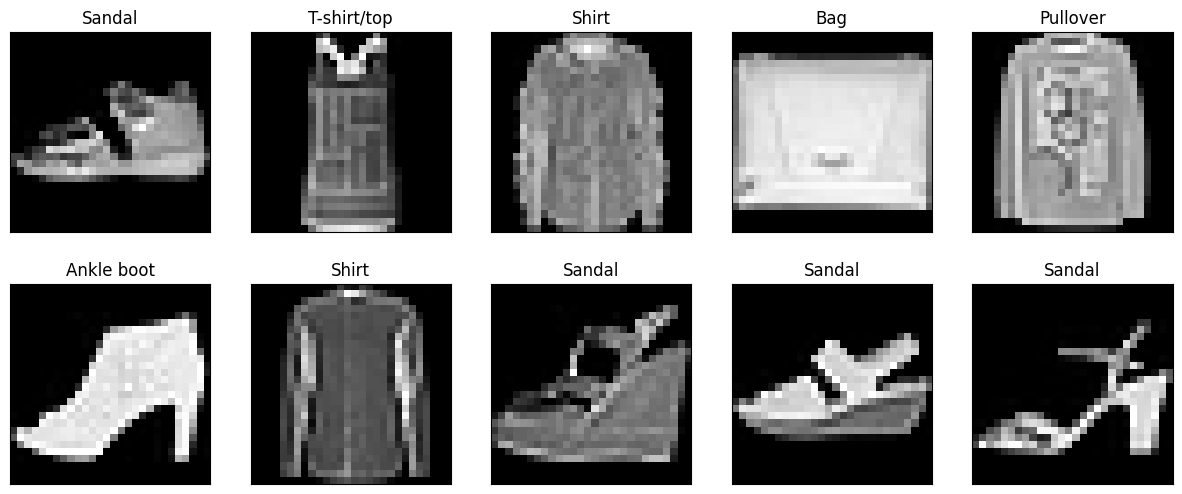

In [5]:
import matplotlib.pyplot as plt
import numpy as np

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

dataiter = iter(train_loader)
images, labels = next(dataiter)

fig = plt.figure(figsize=(15, 6))

for i in np.arange(10):
    x = fig.add_subplot(2, 5, i+1, xticks=[], yticks=[])

    img = images[i].numpy() / 2 + 0.5
    x.imshow(np.squeeze(img), cmap='gray')
    x.set_title(classes[labels[i].item()])

plt.show()

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(32 * 14 * 14, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x


In [7]:
model_1 = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer_1 = torch.optim.SGD(model_1.parameters(),lr=0.01)

In [8]:
epochs = 15

train_loss_1, val_loss_1 = [], []
train_acc_1, val_acc_1 = [], []

for epoch in range(epochs):

    model_1.train()

    running_loss = correct = total = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model_1(images)

        loss = criterion(outputs, labels)

        optimizer_1.zero_grad()

        loss.backward()

        optimizer_1.step()

        running_loss += loss.item()

        total += labels.size(0)

        correct += (outputs.argmax(1) == labels).sum().item()

    train_loss_1.append(running_loss / len(train_loader))

    train_acc_1.append(100 * correct / total)

    # Validation
    model_1.eval()

    val_running_loss = val_correct = val_total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model_1(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            val_total += labels.size(0)

            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_loss_1.append(val_running_loss / len(test_loader))

    val_acc_1.append(100 * val_correct / val_total)

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss_1[-1]:.4f}, Train Acc: {train_acc_1[-1]:.2f}% | Val Loss: {val_loss_1[-1]:.4f}, Val Acc: {val_acc_1[-1]:.2f}%")

Epoch [1/15] | Train Loss: 0.7204, Train Acc: 75.50% | Val Loss: 0.5948, Val Acc: 77.59%
Epoch [2/15] | Train Loss: 0.4609, Train Acc: 83.36% | Val Loss: 0.5143, Val Acc: 80.53%
Epoch [3/15] | Train Loss: 0.4064, Train Acc: 85.42% | Val Loss: 0.3992, Val Acc: 85.84%
Epoch [4/15] | Train Loss: 0.3740, Train Acc: 86.59% | Val Loss: 0.4574, Val Acc: 82.90%
Epoch [5/15] | Train Loss: 0.3502, Train Acc: 87.50% | Val Loss: 0.3716, Val Acc: 86.38%
Epoch [6/15] | Train Loss: 0.3313, Train Acc: 88.07% | Val Loss: 0.3608, Val Acc: 86.97%
Epoch [7/15] | Train Loss: 0.3163, Train Acc: 88.64% | Val Loss: 0.3506, Val Acc: 87.18%
Epoch [8/15] | Train Loss: 0.3040, Train Acc: 89.16% | Val Loss: 0.3423, Val Acc: 87.68%
Epoch [9/15] | Train Loss: 0.2938, Train Acc: 89.48% | Val Loss: 0.3302, Val Acc: 87.87%
Epoch [10/15] | Train Loss: 0.2833, Train Acc: 89.88% | Val Loss: 0.3141, Val Acc: 88.68%
Epoch [11/15] | Train Loss: 0.2744, Train Acc: 90.23% | Val Loss: 0.3017, Val Acc: 88.84%
Epoch [12/15] | Tra

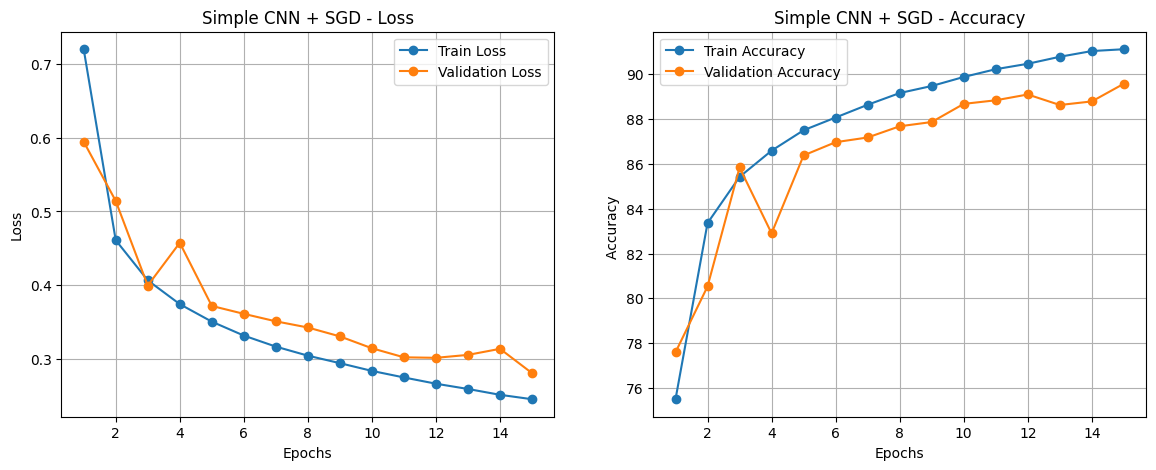

In [9]:
epochs_range = range(1, epochs + 1)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss_1, label='Train Loss', marker='o')
plt.plot(epochs_range, val_loss_1, label='Validation Loss', marker='o')
plt.title('Simple CNN + SGD - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc_1, label='Train Accuracy', marker='o')
plt.plot(epochs_range, val_acc_1, label='Validation Accuracy', marker='o')
plt.title('Simple CNN + SGD - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy ')
plt.legend()
plt.grid(True)

plt.show()

In [10]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        x = self.dropout(x)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x




In [11]:
model_2 = ImprovedCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer_2 = optim.Adam(model_2.parameters(),lr=0.001)

scheduler = optim.lr_scheduler.StepLR(optimizer_2,step_size=5,gamma=0.5)


In [12]:
epochs = 15

train_loss_2, val_loss_2 = [], []
train_acc_2, val_acc_2 = [], []

for epoch in range(epochs):

    model_2.train()

    running_loss = correct = total = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model_2(images)

        loss = criterion(outputs, labels)

        optimizer_2.zero_grad()

        loss.backward()

        optimizer_2.step()

        running_loss += loss.item()

        total += labels.size(0)

        correct += (outputs.argmax(1) == labels).sum().item()

    train_loss_2.append(running_loss / len(train_loader))

    train_acc_2.append(100 * correct / total)

    # Scheduler Step
    scheduler.step()

    # --- Validation ---
    model_2.eval()

    val_running_loss = val_correct = val_total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model_2(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            val_total += labels.size(0)

            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_loss_2.append(val_running_loss / len(test_loader))

    val_acc_2.append(100 * val_correct / val_total)

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss_2[-1]:.4f}, Train Acc: {train_acc_2[-1]:.2f}% | Val Loss: {val_loss_2[-1]:.4f}, Val Acc: {val_acc_2[-1]:.2f}%")

Epoch [1/15] | Train Loss: 0.4004, Train Acc: 85.36% | Val Loss: 0.3296, Val Acc: 87.74%
Epoch [2/15] | Train Loss: 0.2788, Train Acc: 89.73% | Val Loss: 0.2815, Val Acc: 89.41%
Epoch [3/15] | Train Loss: 0.2414, Train Acc: 90.95% | Val Loss: 0.2496, Val Acc: 90.65%
Epoch [4/15] | Train Loss: 0.2162, Train Acc: 91.97% | Val Loss: 0.2563, Val Acc: 90.27%
Epoch [5/15] | Train Loss: 0.1959, Train Acc: 92.73% | Val Loss: 0.2387, Val Acc: 91.40%
Epoch [6/15] | Train Loss: 0.1563, Train Acc: 94.24% | Val Loss: 0.2131, Val Acc: 92.47%
Epoch [7/15] | Train Loss: 0.1459, Train Acc: 94.56% | Val Loss: 0.2217, Val Acc: 92.51%
Epoch [8/15] | Train Loss: 0.1357, Train Acc: 95.03% | Val Loss: 0.2175, Val Acc: 92.08%
Epoch [9/15] | Train Loss: 0.1244, Train Acc: 95.30% | Val Loss: 0.2151, Val Acc: 92.72%
Epoch [10/15] | Train Loss: 0.1160, Train Acc: 95.61% | Val Loss: 0.2212, Val Acc: 92.87%
Epoch [11/15] | Train Loss: 0.0946, Train Acc: 96.46% | Val Loss: 0.2151, Val Acc: 92.92%
Epoch [12/15] | Tra

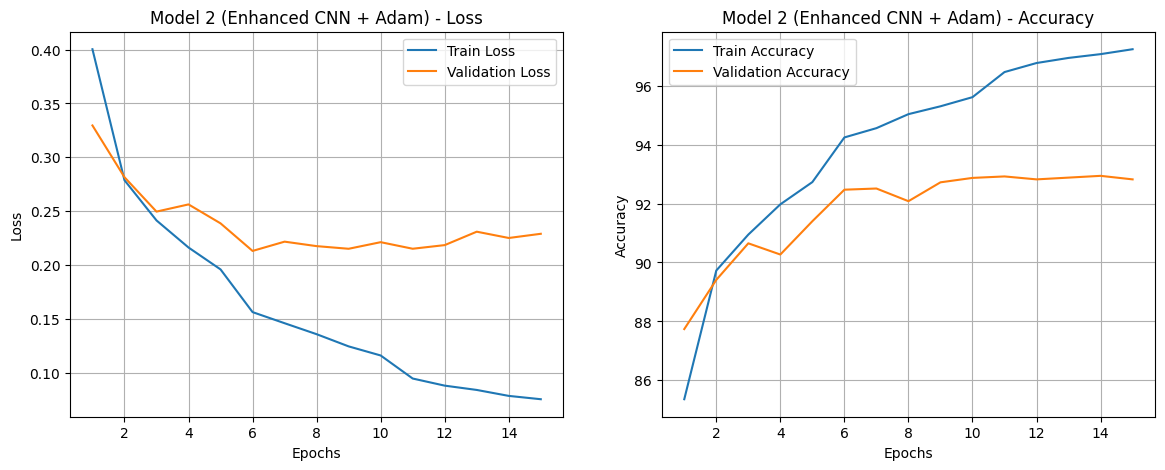

In [13]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss_2, label='Train Loss')
plt.plot(epochs_range, val_loss_2, label='Validation Loss')
plt.title('Model 2 (Enhanced CNN + Adam) - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc_2, label='Train Accuracy')
plt.plot(epochs_range, val_acc_2, label='Validation Accuracy')
plt.title('Model 2 (Enhanced CNN + Adam) - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [14]:
import pandas as pd

print("\n" + "="*50)
print("             FINAL RESULTS COMPARISON")
print("="*50)

data = {
    "Model Experiment": ["Model 1 (Simple + SGD)", "Model 2 (Enhanced + Adam)"],
    "Final Accuracy ": [f"{val_acc_1[-1]:.2f}%", f"{val_acc_2[-1]:.2f}%"],
    "Final Loss": [f"{val_loss_1[-1]:.4f}", f"{val_loss_2[-1]:.4f}"]
}

results_df = pd.DataFrame(data)
print(results_df.to_string(index=False))


             FINAL RESULTS COMPARISON
         Model Experiment Final Accuracy  Final Loss
   Model 1 (Simple + SGD)          89.58%     0.2802
Model 2 (Enhanced + Adam)          92.82%     0.2290


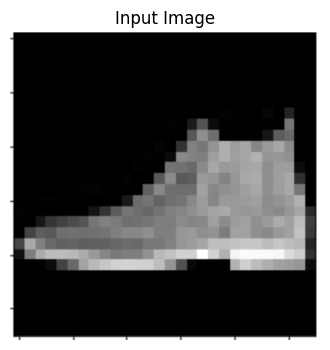

Predicted Class: Ankle boot
Wrong Prediction 


In [15]:
from PIL import Image
import torchvision.transforms as transforms


image_path = "/content/Screenshot 2026-05-16 143144.png"

image = Image.open(image_path).convert('L')


plt.figure(figsize=(4,4))

plt.imshow(image, cmap='gray')

plt.title("Input Image")

plt.axis('off')

plt.show()


transform_image = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

image_tensor = transform_image(image).unsqueeze(0).to(device)



model_2.eval()

with torch.no_grad():

    output = model_2(image_tensor)

    _, predicted = torch.max(output, 1)

predicted_class = classes[predicted.item()]

print("Predicted Class:", predicted_class)


if predicted_class == "Bag":

    print("Correct Prediction ")

else:

    print("Wrong Prediction ")